In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

### Create a box

In [2]:
from cobox import Box

# Create box
N, L = 64, 250.0             
box = Box(N, L, D=3)

# Some box attributes
print(f"Resolution: {box.R:0.3f}")
print(f"Box volume: {box.V:0.3f}")
print(f"Cell volume: {box.CELL_V:0.3f}")
print(f"Spectral resolution: {box.K_RES:0.3f}")
print(f"Nyquist: {box.K_NYQ:0.3f}")
print(f"Corner Nyquist: {box.K_NYQ_CORNER:0.3f}")

Resolution: 3.906
Box volume: 15625000.000
Cell volume: 59.605
Spectral resolution: 0.025
Nyquist: 0.804
Corner Nyquist: 1.393


### Background Cosmology
Example plot of Hubble rate and comoving distance vs redshift

h = 0.6766
Omega_m = 0.3097
Omega_L = 0.6903


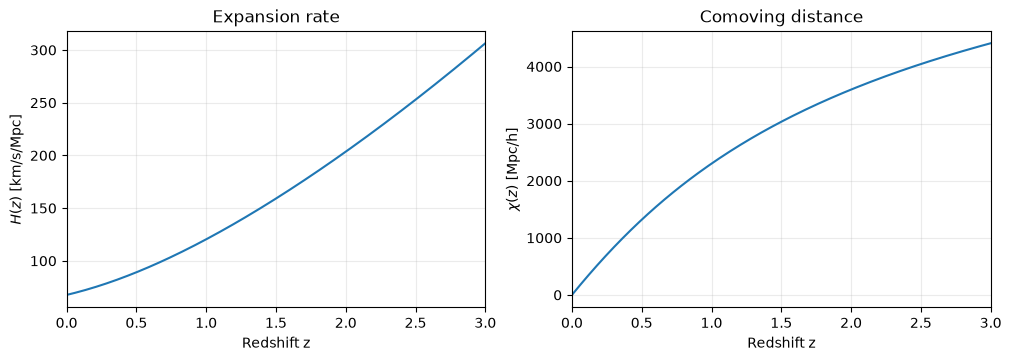

In [3]:
from colcdm import Cosmology, a_of_z

# Load planck28 cosmology
cosmology = Cosmology.from_preset("planck18")
print(f"h = {cosmology.h:.4f}")
print(f"Omega_m = {cosmology.Omega_m:.4f}")
print(f"Omega_L = {cosmology.Omega_de:.4f}")

z = jnp.linspace(0, 3, 200)
a = a_of_z(z)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
axes[0].plot(z, cosmology.H(a))
axes[0].set(title="Expansion rate", ylabel=r"$H(z)$ [km/s/Mpc]")

axes[1].plot(z, cosmology.chi_of_a(a))
axes[1].set(title="Comoving distance", ylabel=r"$\chi(z)$ [Mpc/h]")

for ax in axes:
    ax.set_xlabel("Redshift z")
    ax.set_xlim(0, 3)
    ax.grid(alpha=0.25)

plt.show()


### Linear Matter Power Spectrum

sigma_8 = 0.8223


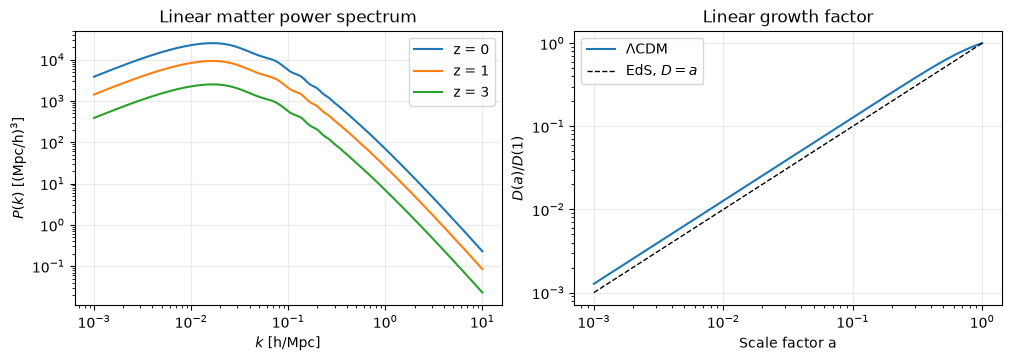

In [4]:
from colcdm import LinearMatterPowSpec

# P(k) linear matter with 'symbolic_pofk'
pk = LinearMatterPowSpec(
    transfer_kind="symbolic_pofk",
    growth_kind="symbolic_pofk",
    cosmology=cosmology,
)
print(f"sigma_8 = {float(pk.sigma8()):.4f}")


k = jnp.logspace(-3, 1, 400)  # [h/Mpc]
a = jnp.logspace(-3, 0, 200)
D = pk.linear_growth(a) / pk.linear_growth(1.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
for z_i in (0.0, 1.0, 3.0):
    axes[0].loglog(k, pk.pk(k, a_of_z(z_i)), label=f"z = {z_i:g}")
axes[0].set(
    title="Linear matter power spectrum",
    xlabel=r"$k$ [h/Mpc]",
    ylabel=r"$P(k)$ [(Mpc/h)$^3$]",
)
axes[0].legend()

axes[1].loglog(a, D, label=r"$\Lambda$CDM")
axes[1].loglog(a, a, "k--", lw=1, label=r"EdS, $D = a$")
axes[1].set(
    title="Linear growth factor",
    xlabel="Scale factor a",
    ylabel=r"$D(a) / D(1)$",
)
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.25)

plt.show()

### Gaussian random fields
Three samplers with the same seed and $P(k)$: 
- white noise in real space,
- Hermitian-packed complex Fourier modes, 
- and the same complex sampler restricted by an isotropic mode mask (here a low-pass $|k| < 0.3$ h/Mpc).

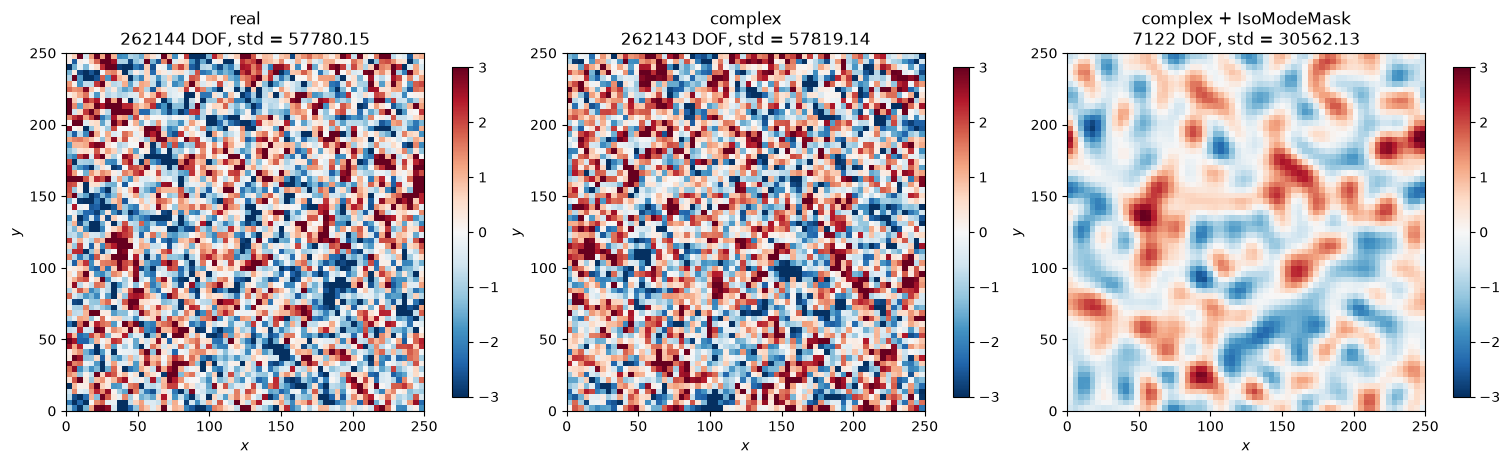

{'u': Array([ 1.6226422 ,  2.0252647 , -0.43359444, ..., -0.14285848,
         2.806447  ,  0.0821657 ], dtype=float32)}

In [5]:
from cobox import GRFSampler, IsoModeMask

iso_mode_mask = IsoModeMask("custom", k_range=(None, 0.3))

samplers = {
    "real": GRFSampler(kind="real"),
    "complex": GRFSampler(kind="complex", complex_base="cartesian"),
    "complex + IsoModeMask": GRFSampler(
        kind="complex",
        complex_base="cartesian",
        restrictions=iso_mode_mask,
    ),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), layout="constrained")
for ax, (name, sampler) in zip(axes, samplers.items()):
    delta0 = sampler.sample_from_seed(0, box, pk)  # pk(k) at a = 1
    n_dof = sampler.get_n_dof(box)["u"]
    delta0.paint(
        ax=ax, axis=2, slab=N // 2, cmap="RdBu_r", vmin=-3, vmax=3,
        title=f"{name}\n{n_dof} DOF, std = {float(delta0.data.std()):.2f}",
    )

plt.show()

# You can access the white noise random numbers by 
samplers["complex"].get_randoms(seed=0, box=box)

### Windows
NGP, CIC and Gaussian windows

Profiles and convolutions (at 2 cell width)

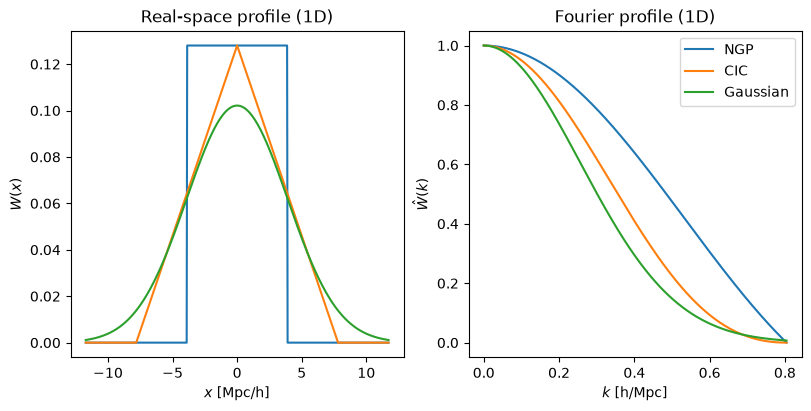

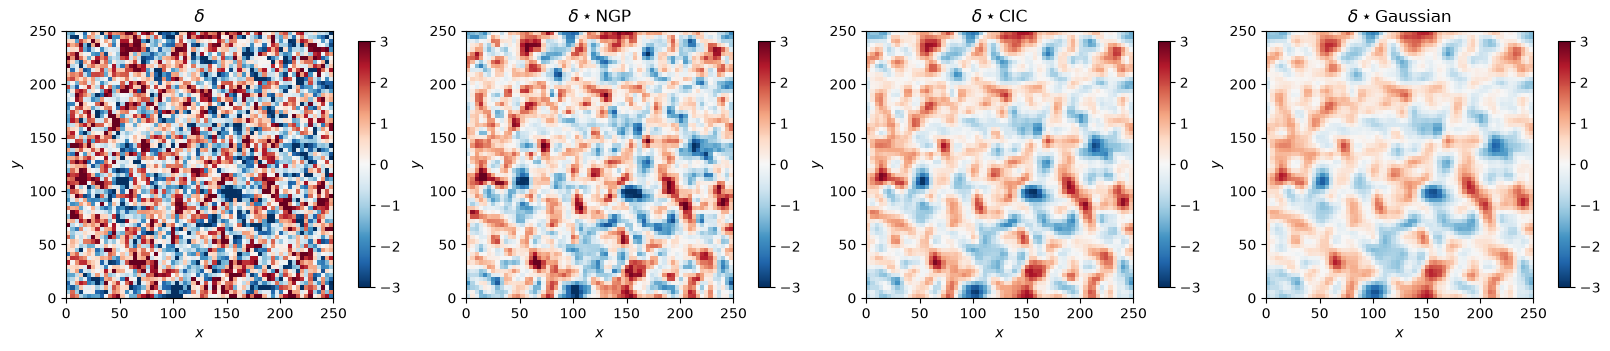

In [6]:
from cobox import Window

# One complex-cartesian realization, kept in Fourier space.
sampler = GRFSampler(kind="complex", complex_base="cartesian")
delta = sampler.sample_from_seed(0, box, pk)

scale = 2*box.R  # 2 cells
windows = {
    "NGP": Window("ngp", scale=scale, normalized=True),
    "CIC": Window("cic", scale=scale, normalized=True),
    "Gaussian": Window("gaussian", scale=scale, normalized=True),
}

x = jnp.linspace(-1.5 * scale, 1.5 * scale, 601)
kk = jnp.linspace(0.0, box.K_NYQ, 400)

fig, axes = plt.subplots(1, 2, figsize=(8, 4), layout="constrained")
for name, w in windows.items():
    axes[0].plot(x, w.win_profile(x), label=name)
    axes[1].plot(kk, w.win_profile_hat(kk), label=name)

axes[0].set(title="Real-space profile (1D)", xlabel=r"$x$ [Mpc/h]", ylabel=r"$W(x)$")
axes[1].set(title="Fourier profile (1D)", xlabel=r"$k$ [h/Mpc]", ylabel=r"$\hat W(k)$")

axes[1].legend(loc="upper right")

fig, axes = plt.subplots(1, 4, figsize=(16, 4), layout="constrained")

vmin, vmax = -3, 3
view = dict(axis=2, slab=N // 2, cmap="RdBu_r")
delta.paint(ax=axes[0], **view, vmin=vmin, vmax=vmax, title=r"$\delta$")
for ax, (name, w) in zip(axes[1:], windows.items()):
    delta.convolve(w).paint(ax=ax, **view, vmin=vmin, vmax=vmax, title=rf"$\delta \star${name}")
plt.show()

### ScalarField methods

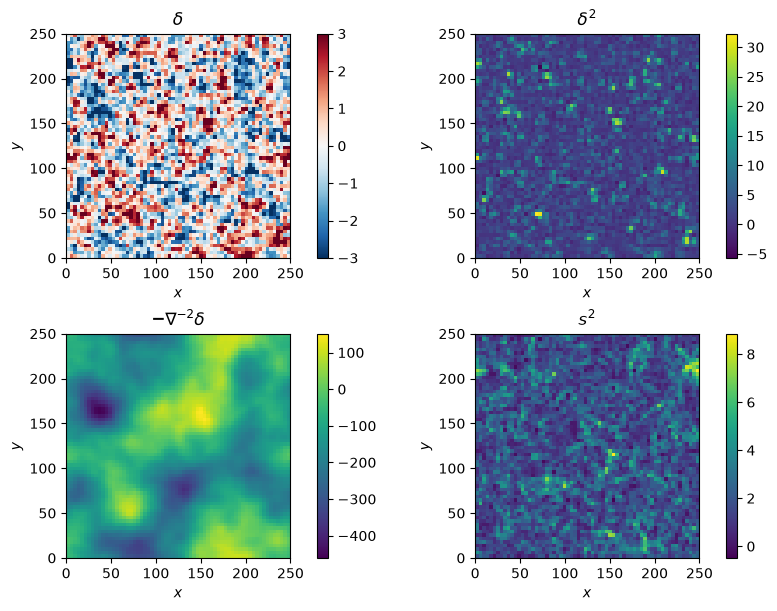

In [7]:
nyquist_iso_mask = IsoModeMask("nyquist_open")
sampler = GRFSampler(kind="complex", complex_base="cartesian", restrictions=nyquist_iso_mask)
delta = sampler.sample_from_seed(0, box, pk)

delta_sq = delta.square(dealias=True, N_iso=box.N)
potential = -delta.inv_laplacian() 
s2 = delta.s_sq(dealias=True, N_iso=box.N)

fig, axes = plt.subplots(2, 2, figsize=(8, 6), layout="constrained")

view = dict(axis=2, slab=N // 2)

delta.paint(ax=axes[0,0], **view, vmin=-3, vmax=3, title=r"$\delta$", cmap="RdBu_r")
delta_sq.paint(ax=axes[0,1], **view, title=r"$\delta^2$")
potential.paint(ax=axes[1,0], **view, title=r"$-\nabla^{-2} \delta$")
s2.paint(ax=axes[1,1], **view, title=r"$s^2$")

plt.show()

### LPT
Norm of the displacement at orders 1 to 3 from the same initial field.

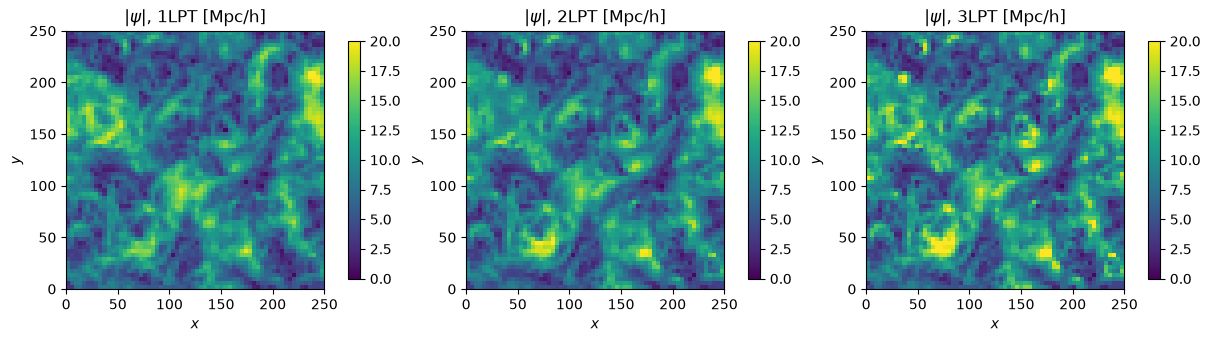

In [8]:
from cobox import ScalarField
from colcdm import LPT

a = 1.0

fig, axes = plt.subplots(1, 3, figsize=(12, 4), layout="constrained")
for ax, order in zip(axes, (1, 2, 3)):
    psi = LPT(delta, order).get_psi(a, cosmology).ifft()
    psi_norm = psi.norm()
    psi_norm.paint(
        ax=ax, axis=2, slab=N // 2, cmap="viridis", vmin=0, vmax=20,
        title=rf"$|\psi|$, {order}LPT [Mpc/h]",
    )
plt.show()

Scatter of $\nabla \cdot \boldsymbol{\Psi}$

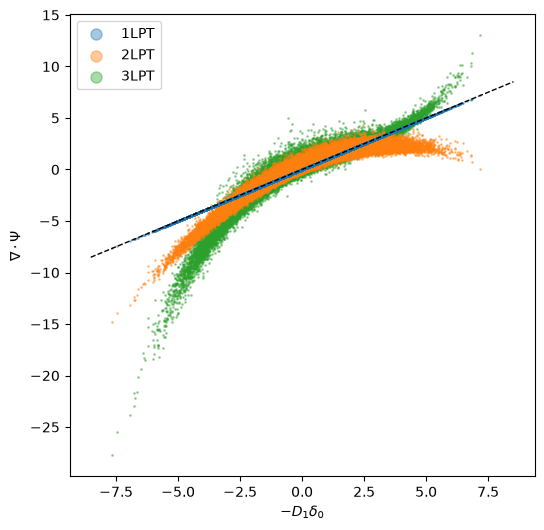

In [91]:
a = 1.0
D1 = LPT(delta, 1).coeffs(a, cosmology)["1"]  # D(a) / D(1)

x = (-D1 * delta.ifft().data).ravel()

rng = np.random.default_rng(0)
idx = rng.choice(x.size, size=100_000, replace=False)  # subsample for plotting

fig, ax = plt.subplots(figsize=(6, 6))
for order in (1, 2, 3):  # 1LPT drawn last, on top
    div_psi = LPT(delta, order).get_psi(a, cosmology).div().ifft().data.ravel()
    ax.scatter(x[idx], div_psi[idx], s=1, alpha=0.4, label=f"{order}LPT", zorder=-order)

lim = float(np.abs(x).max())
ax.plot([-lim, lim], [-lim, lim], "k--", lw=1)
ax.set(xlabel=r"$-D_1 \delta_0$", ylabel=r"$\nabla \cdot \Psi$")
ax.legend(markerscale=8)
plt.show()


### Particles and mass assignment
The lattice is displaced by the 2LPT displacement and then deposited back onto the
grid with the NGP, CIC and TSC schemes (`bspline_order` 0, 1, 2). The particle
scatter and the density panels show the same 3-cell slab through the box centre.
Higher orders spread each particle over more cells, giving smoother fields.


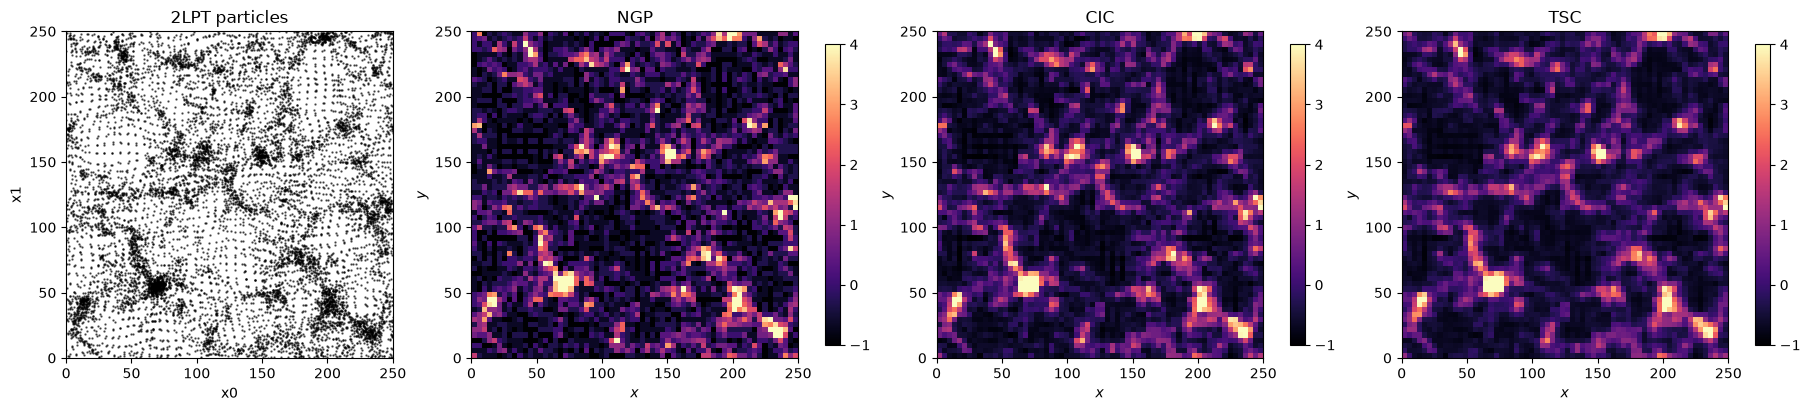

In [9]:
from cobox import Particles
from colcdm import LPT

a = 1.0
psi = LPT(delta, 2).get_psi(a, cosmology)

particles = Particles(box).displace_from_vector_field(psi, interpolation=None)

# bspline_order: 0 = NGP, 1 = CIC, 2 = TSC. Node convention: cell j is centred on j * R.
densities = {
    name: particles.deposit(N, bspline_order=order, return_contrast=True)
    for name, order in (("NGP", 0), ("CIC", 1), ("TSC", 2))
}

# The same slab for particles and fields: `width` cells centred on `slab`.
slab, width = N // 2, 3
first = slab - width // 2
particle_slab = (first - 0.5, first + width - 0.5)  # cell units

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), layout="constrained")
particles.paint(ax=axes[0], axis=2, slab=particle_slab, s=0.5, alpha=0.6, c="k", title="2LPT particles")
for ax, (name, rho) in zip(axes[1:], densities.items()):
    rho.paint(ax=ax, axis=2, slab=slab, width=width, cmap="magma", vmin=-1, vmax=4, title=name)
plt.show()


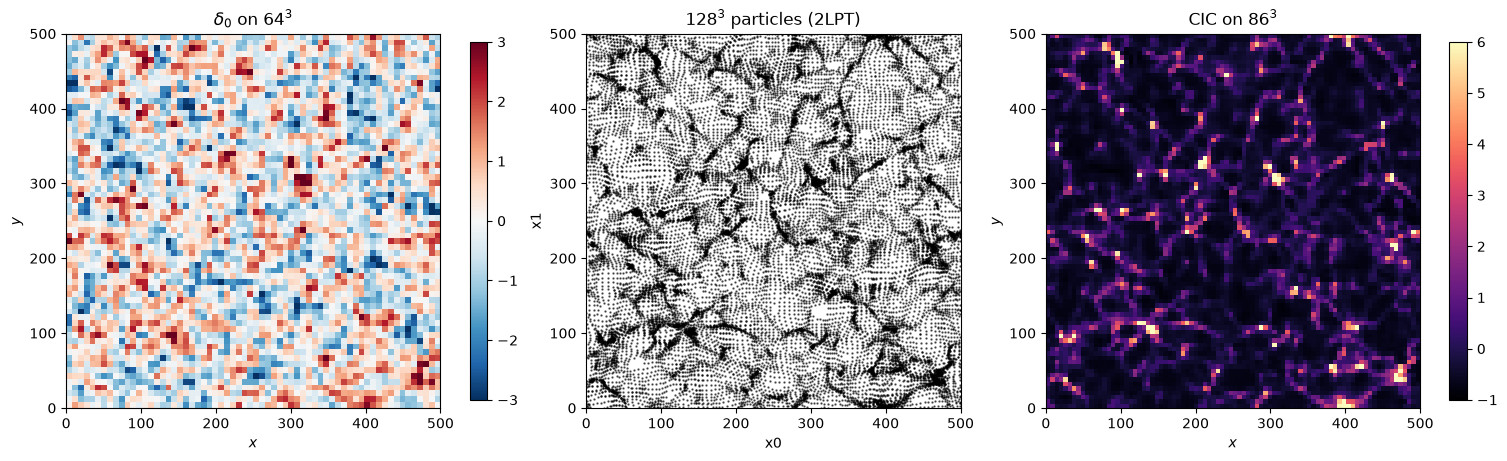

In [22]:
from cobox import GRFSampler, IsoModeMask, Particles
from colcdm import LPT

a = 1.0
L = 500

N = 64  # delta0 resolution
N_P = 128  # particles per side (even)
N_G = 86  # deposit grid per side

# Band-limited initial field on the N grid: |k_idx| < N/2.
sampler = GRFSampler(kind="complex", complex_base="cartesian", restrictions=IsoModeMask("nyquist_open"))
delta0 = sampler.sample_from_seed(0, Box(N=N, L=L, D=3), pk)

# N_iso declares the band limit; out_N resamples the basis onto the particle lattice.
lpt = LPT(delta0, order=2, N_iso=N, out_N="full")
psi = lpt.get_psi(a, cosmology)

particles = Particles(Box(N=N_P, L=L, D=3)).displace_from_vector_field(psi, interpolation="linear")
rho = particles.deposit(N_G, bspline_order=1, bspline_scale="particles", return_contrast=True)  # CIC on the N_G grid

# One N_G cell thick slab through the centre, in world units for the particles.
R_G = L / N_G
z0 = (N_G // 2 - 0.5) * R_G

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), layout="constrained")
delta0.paint(ax=axes[0], axis=2, slab=N // 2, cmap="RdBu_r", vmin=-3, vmax=3, title=rf"$\delta_0$ on {N}$^3$")
particles.paint(
    ax=axes[1], axis=2, slab=(z0, z0 + R_G), units=True, s=0.5, alpha=0.6, c="k",
    title=f"{N_P}$^3$ particles (2LPT)",
)
rho.paint(ax=axes[2], axis=2, slab=N_G // 2, cmap="magma", vmin=-1, vmax=6, title=f"CIC on {N_G}$^3$")
plt.show()


### Statistics

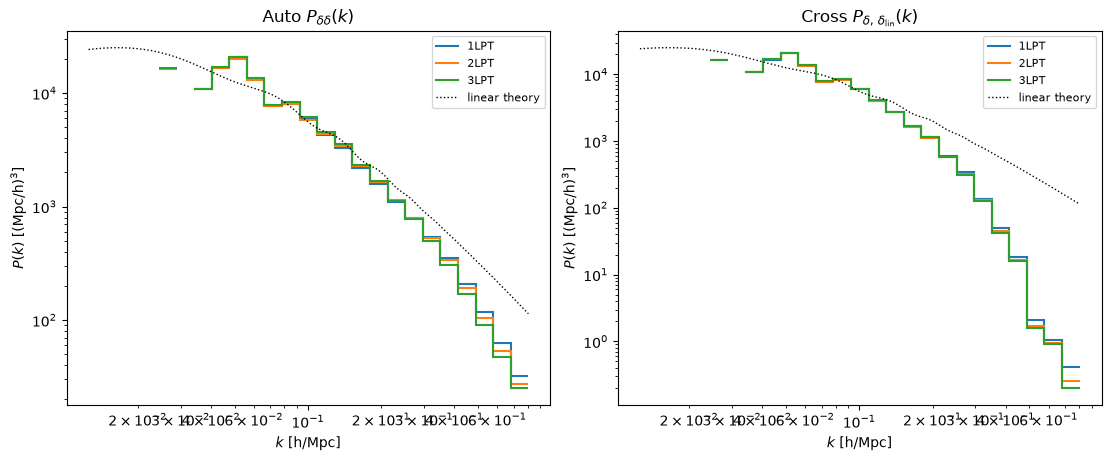

In [14]:
from cobox import Particles, stats
from colcdm import LPT

a = 1.0
lattice = Particles(box)

# One CIC deposit per LPT order.
densities = {
    f"{order}LPT": lattice.displace_from_vector_field(
        LPT(delta, order).get_psi(a, cosmology), interpolation="linear"
    ).deposit(N, bspline_order=1, return_contrast=True)
    for order in (1, 2, 3)
}

# Cross against the linear field D1 delta_0 on shared bins.
D1 = LPT(delta, 1).coeffs(a, cosmology)["1"]
delta_lin = delta * D1
bins = stats.KBins.log(box, 25)
cross = {name: stats.cross_spectrum(rho, delta_lin, bins=bins) for name, rho in densities.items()}

kk = jnp.logspace(jnp.log10(box.K_RES / 2), jnp.log10(box.K_NYQ), 200)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")
for name, cs in cross.items():
    cs.aa.plot(ax=axes[0], lw=1.5, label=name)
    cs.ab.plot(ax=axes[1], lw=1.5, label=name)

for ax in axes:
    ax.plot(kk, pk(kk, a), "k:", lw=1, label="linear theory")
    ax.set(xlabel=r"$k$ [h/Mpc]", ylabel=r"$P(k)$ [(Mpc/h)$^3$]")
    ax.legend(fontsize=8)
axes[0].set_title(r"Auto $P_{\delta\delta}(k)$")
axes[1].set_title(r"Cross $P_{\delta,\,\delta_{\rm lin}}(k)$")
plt.show()
